AIRFLY INSIGHTS : DATA VISUALIZATION AND ANALYSIS OF AIRLINE OPERATIONS


In [62]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [63]:
!ls /content/drive/MyDrive/flights.csv

/content/drive/MyDrive/flights.csv


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)


In [65]:
df= pd.read_csv("/content/drive/MyDrive/flights.csv", low_memory=False)
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
df.shape

(5819079, 31)

In [67]:
df.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [69]:
df.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,5.819073e+06,5.714008e+06,5.714008e+06,5.819079e+06,5.726566e+06,5.726566e+06,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,1.416859e+02,1.370062e+02,1.135116e+02,8.223565e+02,1.471469e+03,7.434971e+00,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,7.521058e+01,7.421107e+01,7.223082e+01,6.077843e+02,5.221879e+02,5.638548e+00,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,1.800000e+01,1.400000e+01,7.000000e+00,2.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,8.500000e+01,8.200000e+01,6.000000e+01,3.730000e+02,1.054000e+03,4.000000e+00,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,1.230000e+02,1.180000e+02,9.400000e+01,6.470000e+02,1.509000e+03,6.000000e+00,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,1.730000e+02,1.680000e+02,1.440000e+02,1.062000e+03,1.911000e+03,9.000000e+00,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,7.180000e+02,7.660000e+02,6.900000e+02,4.983000e+03,2.400000e+03,2.480000e+02,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


In [70]:
df.isnull().sum().sort_values(ascending=False)


,0
CANCELLATION_REASON,5729195
LATE_AIRCRAFT_DELAY,4755640
WEATHER_DELAY,4755640
AIRLINE_DELAY,4755640
AIR_SYSTEM_DELAY,4755640
SECURITY_DELAY,4755640
ELAPSED_TIME,105071
AIR_TIME,105071
ARRIVAL_DELAY,105071
WHEELS_ON,92513


In [71]:
df.memory_usage(deep=True)


,0
Index,132
YEAR,46552632
MONTH,46552632
DAY,46552632
DAY_OF_WEEK,46552632
AIRLINE,296773029
FLIGHT_NUMBER,46552632
TAIL_NUMBER,319695659
ORIGIN_AIRPORT,303564438
DESTINATION_AIRPORT,303564438


In [72]:
df['YEAR'] = df['YEAR'].astype('int16')
df['MONTH'] = df['MONTH'].astype('int8')
df['DAY_OF_WEEK'] = df['DAY_OF_WEEK'].astype('int8')


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int16  
 1   MONTH                int8   
 2   DAY                  int64  
 3   DAY_OF_WEEK          int8   
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [74]:
df.memory_usage(deep=True)


,0
Index,132
YEAR,11638158
MONTH,5819079
DAY,46552632
DAY_OF_WEEK,5819079
AIRLINE,296773029
FLIGHT_NUMBER,46552632
TAIL_NUMBER,319695659
ORIGIN_AIRPORT,303564438
DESTINATION_AIRPORT,303564438


In [75]:
df['AIRLINE'] = df['AIRLINE'].astype('category')
df['ORIGIN_AIRPORT'] = df['ORIGIN_AIRPORT'].astype('category')
df['DESTINATION_AIRPORT'] = df['DESTINATION_AIRPORT'].astype('category')


In [76]:
df[['AIRLINE','ORIGIN_AIRPORT','DESTINATION_AIRPORT']].dtypes


,0
AIRLINE,category
ORIGIN_AIRPORT,category
DESTINATION_AIRPORT,category


In [77]:
df.memory_usage(deep=True)


,0
Index,132
YEAR,11638158
MONTH,5819079
DAY,46552632
DAY_OF_WEEK,5819079
AIRLINE,5820349
FLIGHT_NUMBER,46552632
TAIL_NUMBER,319695659
ORIGIN_AIRPORT,11687978
DESTINATION_AIRPORT,11688032


In [78]:
df = df.sample(frac=0.3, random_state=42)


In [79]:
df.shape

(1745724, 31)

In [80]:
df[['ARRIVAL_DELAY','DEPARTURE_DELAY']].isnull().sum()


,0
ARRIVAL_DELAY,31473
DEPARTURE_DELAY,25778


In [81]:
df['ARRIVAL_DELAY'] = df['ARRIVAL_DELAY'].fillna(0)
df['DEPARTURE_DELAY'] = df['DEPARTURE_DELAY'].fillna(0)


In [82]:
df[['ARRIVAL_DELAY','DEPARTURE_DELAY']].isnull().sum()


,0
ARRIVAL_DELAY,0
DEPARTURE_DELAY,0


In [83]:
df['ISCANCELLED'] = df['CANCELLED']


In [84]:
df[['CANCELLED','ISCANCELLED']].head()


,CANCELLED,ISCANCELLED
1508570,0,0
363270,0,0
3003945,0,0
2291425,0,0
2973084,0,0


In [85]:
df['DATE'] = pd.to_datetime(df[['YEAR','MONTH','DAY']])


In [86]:
df[['YEAR','MONTH','DAY','DATE']].head()


,YEAR,MONTH,DAY,DATE
1508570,2015,4,7,2015-04-07
363270,2015,1,24,2015-01-24
3003945,2015,7,8,2015-07-08
2291425,2015,5,26,2015-05-26
2973084,2015,7,6,2015-07-06


In [87]:
df['MONTH_NAME'] = df['DATE'].dt.month_name()


In [88]:
df[['DATE','MONTH_NAME']].head()


,DATE,MONTH_NAME
1508570,2015-04-07,April
363270,2015-01-24,January
3003945,2015-07-08,July
2291425,2015-05-26,May
2973084,2015-07-06,July


In [89]:
df['DAY_NAME'] = df['DATE'].dt.day_name()


In [90]:
df[['DATE','DAY_NAME']].head()


,DATE,DAY_NAME
1508570,2015-04-07,Tuesday
363270,2015-01-24,Saturday
3003945,2015-07-08,Wednesday
2291425,2015-05-26,Tuesday
2973084,2015-07-06,Monday


In [91]:
df['DEP_HOUR'] = df['SCHEDULED_DEPARTURE'] // 100


In [92]:
df[['SCHEDULED_DEPARTURE','DEP_HOUR']].head()


,SCHEDULED_DEPARTURE,DEP_HOUR
1508570,1340,13
363270,1910,19
3003945,630,6
2291425,810,8
2973084,1000,10


In [93]:
df['ROUTE'] = df['ORIGIN_AIRPORT'].astype(str) + " - " + df['DESTINATION_AIRPORT'].astype(str)


In [94]:
df[['ORIGIN_AIRPORT','DESTINATION_AIRPORT','ROUTE']].head()


,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ROUTE
1508570,FWA,DTW,FWA - DTW
363270,LAS,SEA,LAS - SEA
3003945,OAK,SEA,OAK - SEA
2291425,STL,DAL,STL - DAL
2973084,IAH,HNL,IAH - HNL


In [95]:
df.isnull().sum()


,0
YEAR,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
AIRLINE,0
FLIGHT_NUMBER,0
TAIL_NUMBER,4378
ORIGIN_AIRPORT,0
DESTINATION_AIRPORT,0
SCHEDULED_DEPARTURE,0


In [96]:
df.to_csv("/content/drive/MyDrive/flights_cleaned.csv", index=False)


In [97]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/flights_cleaned.csv")
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,ISCANCELLED,DATE,MONTH_NAME,DAY_NAME,DEP_HOUR,ROUTE
0,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,1335.0,-5.0,13.0,1348.0,56.0,48.0,30.0,128,1418.0,5.0,1436,1423.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,2015-04-07,April,Tuesday,13,FWA - DTW
1,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,1858.0,-12.0,14.0,1912.0,155.0,155.0,131.0,867,2123.0,10.0,2145,2133.0,-12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,2015-01-24,January,Saturday,19,LAS - SEA
2,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,626.0,-4.0,8.0,634.0,110.0,106.0,92.0,672,806.0,6.0,820,812.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,2015-07-08,July,Wednesday,6,OAK - SEA
3,2015,5,26,2,WN,193,N7745A,STL,DAL,810,1043.0,153.0,6.0,1049.0,100.0,99.0,85.0,546,1214.0,8.0,950,1222.0,152.0,0,0,NaN,0.0,0.0,0.0,152.0,0.0,0,2015-05-26,May,Tuesday,8,STL - DAL
4,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,1008.0,8.0,16.0,1024.0,498.0,488.0,461.0,3904,1305.0,11.0,1318,1316.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,2015-07-06,July,Monday,10,IAH - HNL


In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/drive/MyDrive/flights_cleaned.csv")
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,ISCANCELLED,DATE,MONTH_NAME,DAY_NAME,DEP_HOUR,ROUTE
0,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,1335.0,-5.0,13.0,1348.0,56.0,48.0,30.0,128,1418.0,5.0,1436,1423.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,2015-04-07,April,Tuesday,13,FWA - DTW
1,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,1858.0,-12.0,14.0,1912.0,155.0,155.0,131.0,867,2123.0,10.0,2145,2133.0,-12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,2015-01-24,January,Saturday,19,LAS - SEA
2,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,626.0,-4.0,8.0,634.0,110.0,106.0,92.0,672,806.0,6.0,820,812.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,2015-07-08,July,Wednesday,6,OAK - SEA
3,2015,5,26,2,WN,193,N7745A,STL,DAL,810,1043.0,153.0,6.0,1049.0,100.0,99.0,85.0,546,1214.0,8.0,950,1222.0,152.0,0,0,NaN,0.0,0.0,0.0,152.0,0.0,0,2015-05-26,May,Tuesday,8,STL - DAL
4,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,1008.0,8.0,16.0,1024.0,498.0,488.0,461.0,3904,1305.0,11.0,1318,1316.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,2015-07-06,July,Monday,10,IAH - HNL


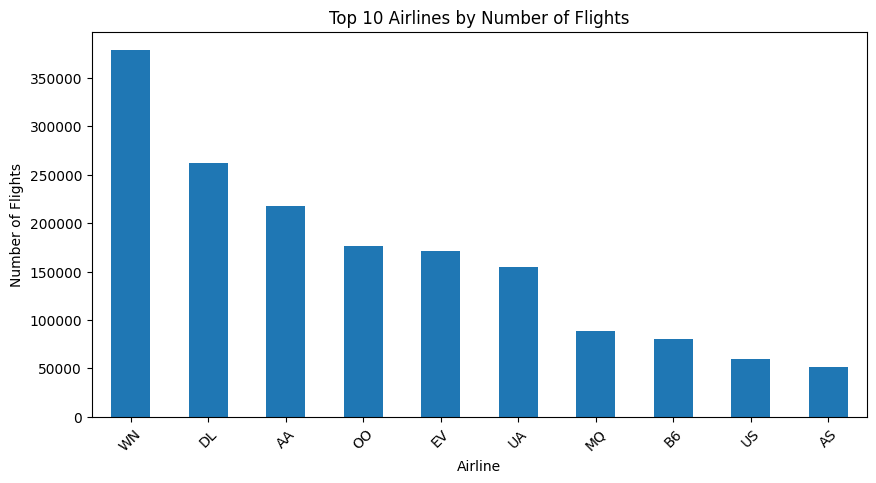

In [99]:
plt.figure(figsize=(10,5))
df['AIRLINE'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Airlines by Number of Flights")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

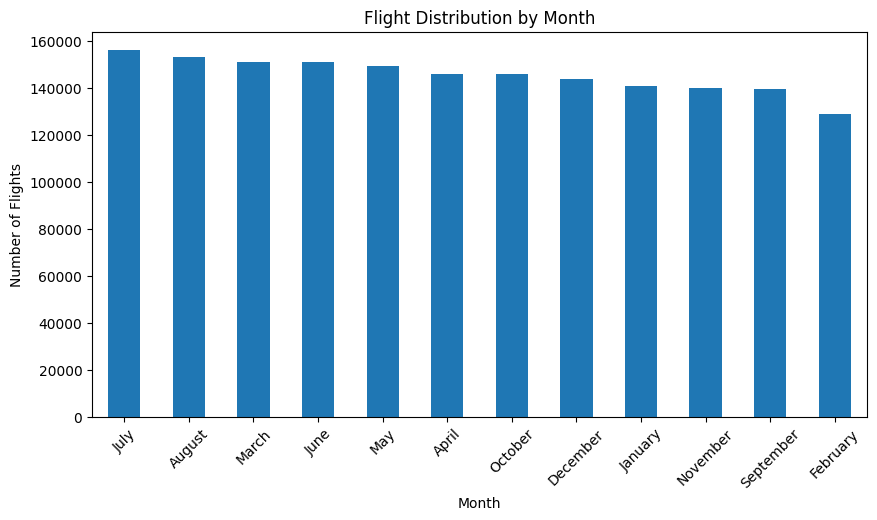

In [100]:
plt.figure(figsize=(10,5))
df['MONTH_NAME'].value_counts().plot(kind='bar')
plt.title("Flight Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

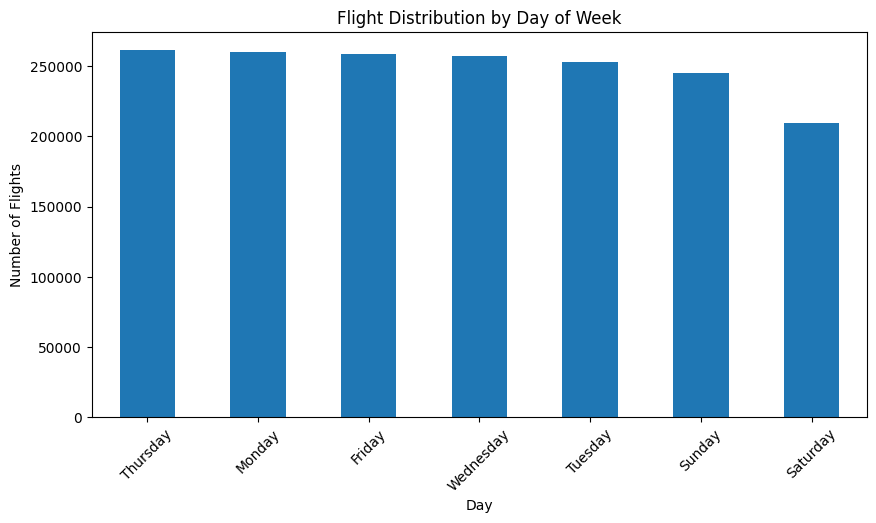

In [101]:
plt.figure(figsize=(10,5))
df['DAY_NAME'].value_counts().plot(kind='bar')
plt.title("Flight Distribution by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

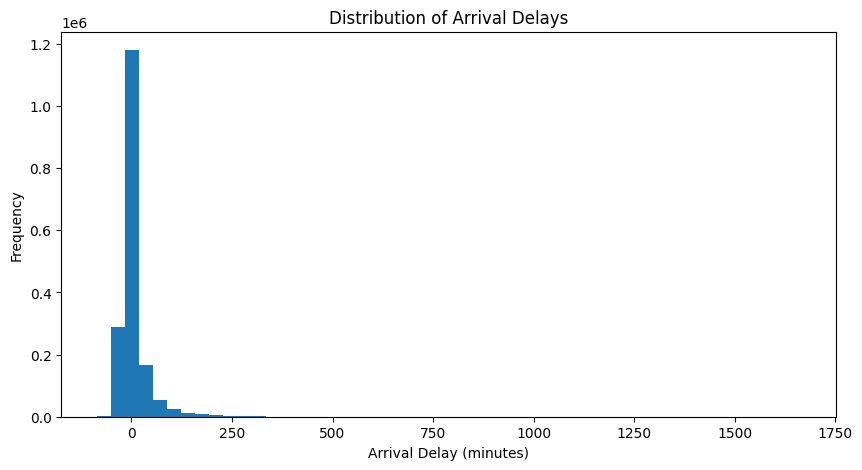

In [102]:
plt.figure(figsize=(10,5))
plt.hist(df['ARRIVAL_DELAY'], bins=50)
plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Frequency")
plt.show()

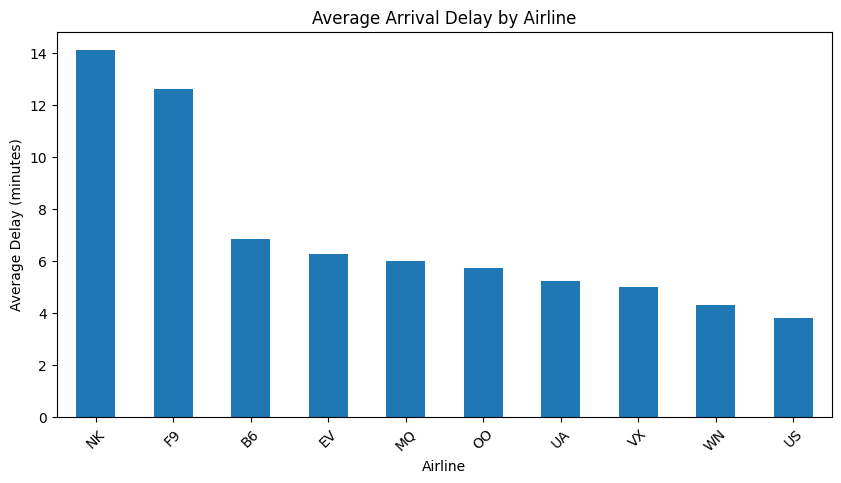

In [103]:
avg_delay = df.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
avg_delay.head(10).plot(kind='bar')
plt.title("Average Arrival Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

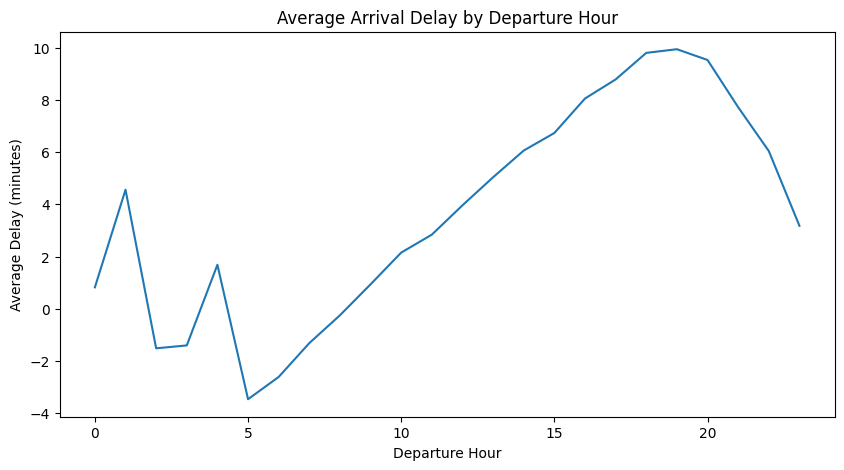

In [104]:
hour_delay = df.groupby('DEP_HOUR')['ARRIVAL_DELAY'].mean()

plt.figure(figsize=(10,5))
hour_delay.plot(kind='line')
plt.title("Average Arrival Delay by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Average Delay (minutes)")
plt.show()

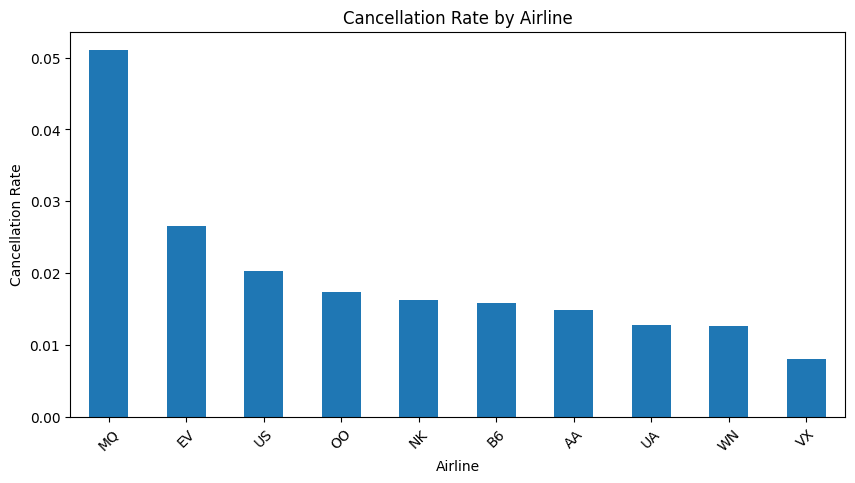

In [105]:
cancel_rate = df.groupby('AIRLINE')['ISCANCELLED'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
cancel_rate.head(10).plot(kind='bar')
plt.title("Cancellation Rate by Airline")
plt.xlabel("Airline")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

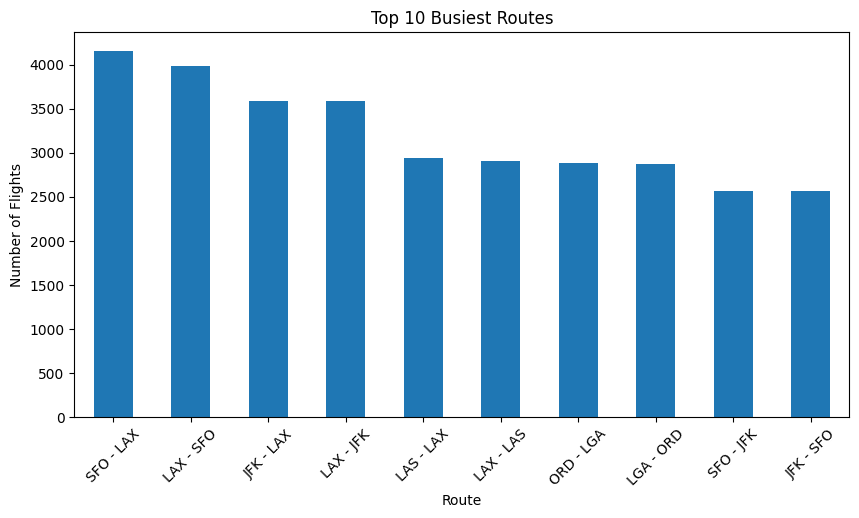

In [106]:
plt.figure(figsize=(10,5))
df['ROUTE'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Busiest Routes")
plt.xlabel("Route")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/flights_cleaned.csv")

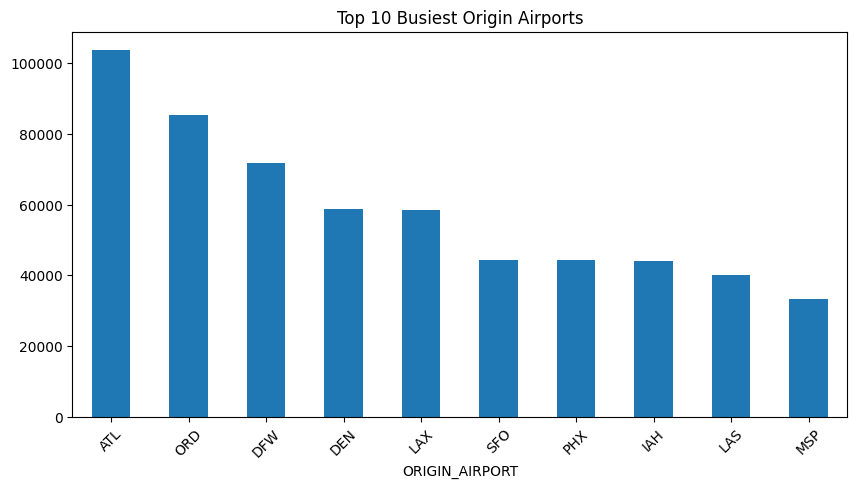

In [108]:
plt.figure(figsize=(10,5))
df['ORIGIN_AIRPORT'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Busiest Origin Airports")
plt.xticks(rotation=45)
plt.show()

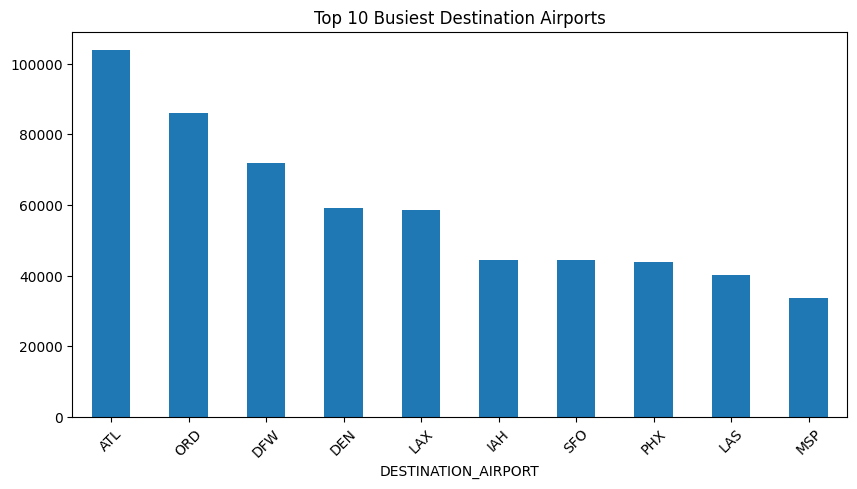

In [109]:
plt.figure(figsize=(10,5))
df['DESTINATION_AIRPORT'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Busiest Destination Airports")
plt.xticks(rotation=45)
plt.show()

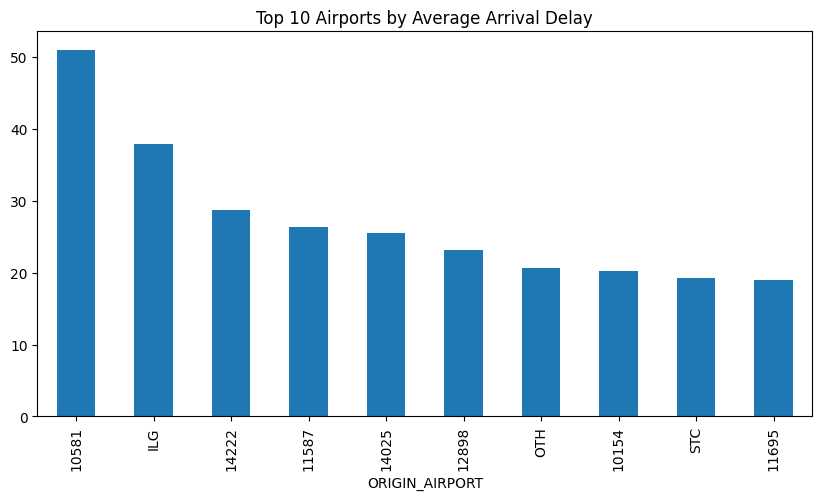

In [110]:
airport_delay = df.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
airport_delay.head(10).plot(kind='bar')
plt.title("Top 10 Airports by Average Arrival Delay")
plt.show()

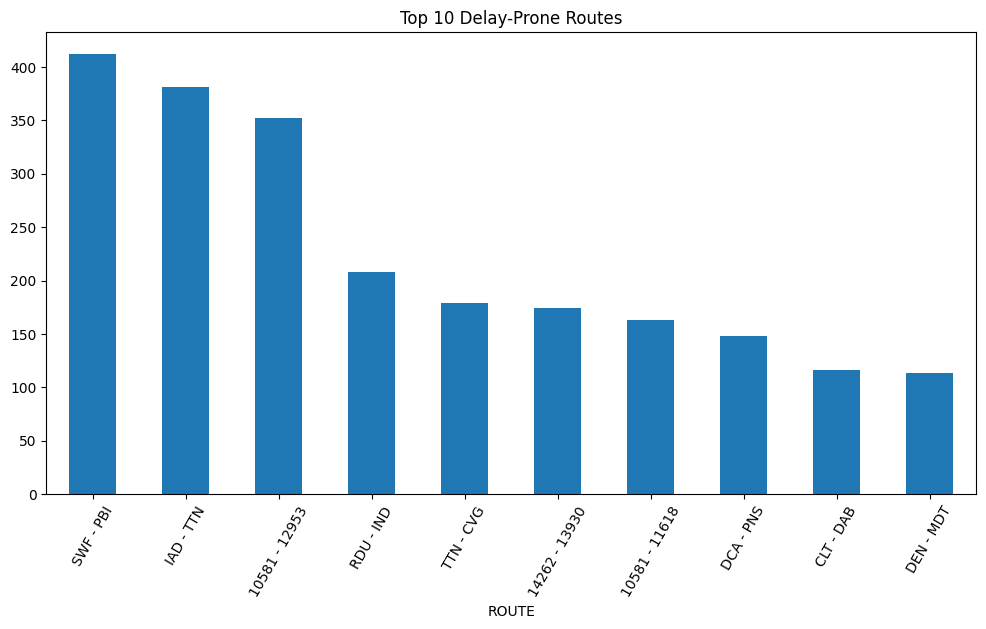

In [111]:
route_delay = df.groupby('ROUTE')['ARRIVAL_DELAY'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
route_delay.head(10).plot(kind='bar')
plt.title("Top 10 Delay-Prone Routes")
plt.xticks(rotation=60)
plt.show()

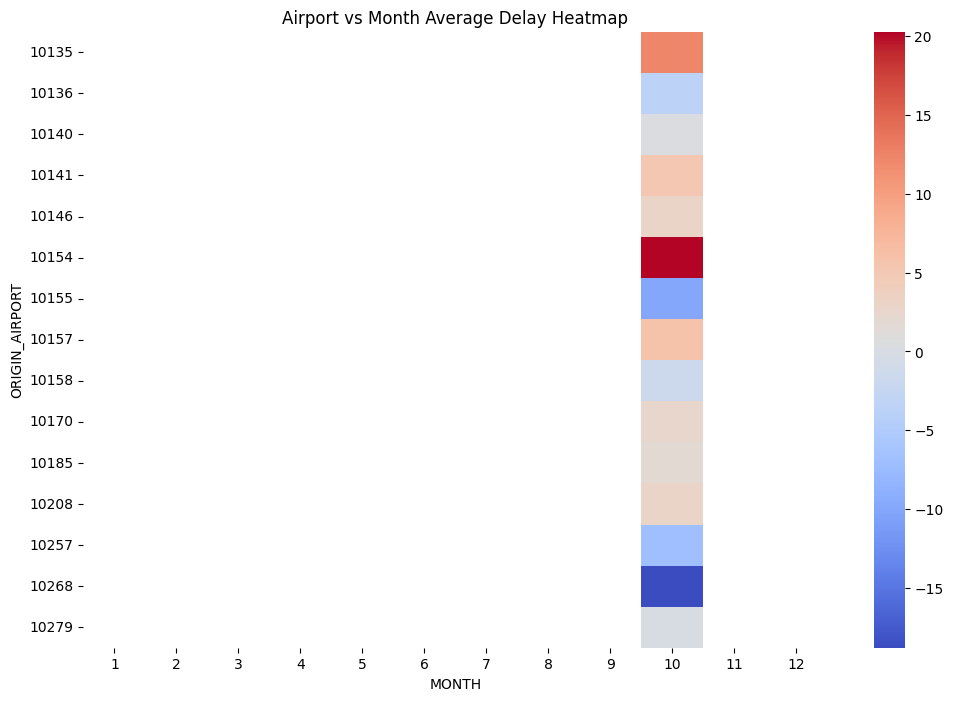

In [112]:
pivot = df.pivot_table(values='ARRIVAL_DELAY',
                       index='ORIGIN_AIRPORT',
                       columns='MONTH',
                       aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(pivot.head(15), cmap="coolwarm")
plt.title("Airport vs Month Average Delay Heatmap")
plt.show()

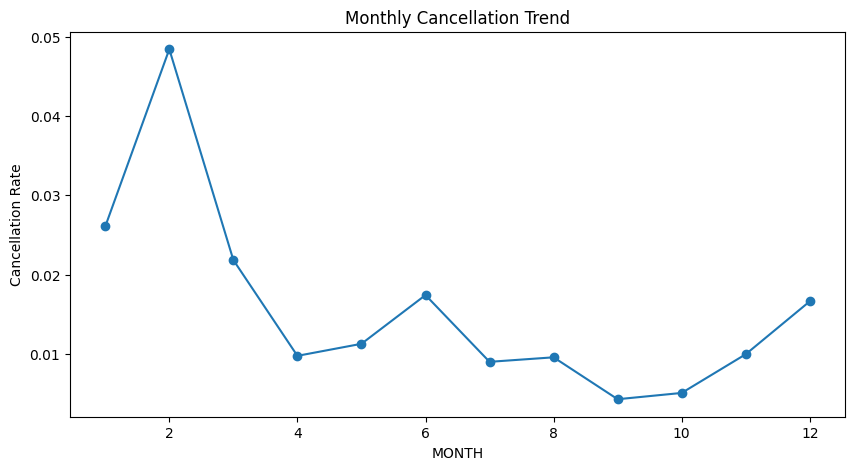

In [113]:
cancel_month = df.groupby('MONTH')['ISCANCELLED'].mean()

plt.figure(figsize=(10,5))
cancel_month.plot(kind='line', marker='o')
plt.title("Monthly Cancellation Trend")
plt.ylabel("Cancellation Rate")
plt.show()

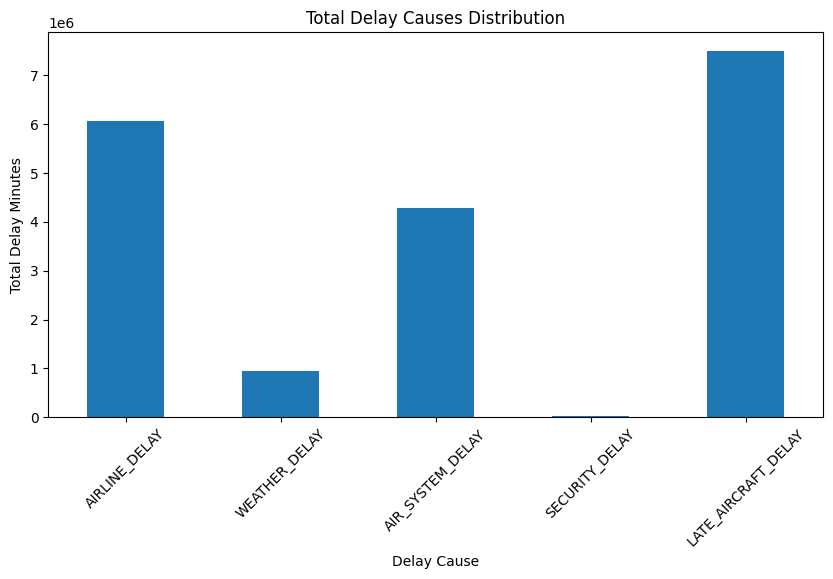

In [114]:
delay_causes = df[
    ['AIRLINE_DELAY',
     'WEATHER_DELAY',
     'AIR_SYSTEM_DELAY',
     'SECURITY_DELAY',
     'LATE_AIRCRAFT_DELAY']
].sum()

plt.figure(figsize=(10,5))
delay_causes.plot(kind='bar')
plt.title("Total Delay Causes Distribution")
plt.xlabel("Delay Cause")
plt.ylabel("Total Delay Minutes")
plt.xticks(rotation=45)
plt.show()

In [115]:
winter = df[df['MONTH'].isin([12,1,2])]
non_winter = df[~df['MONTH'].isin([12,1,2])]

print("Winter Avg Delay:", winter['ARRIVAL_DELAY'].mean())
print("Non-Winter Avg Delay:", non_winter['ARRIVAL_DELAY'].mean())

Winter Avg Delay: 6.419870446909821
Non-Winter Avg Delay: 3.7009521063908695


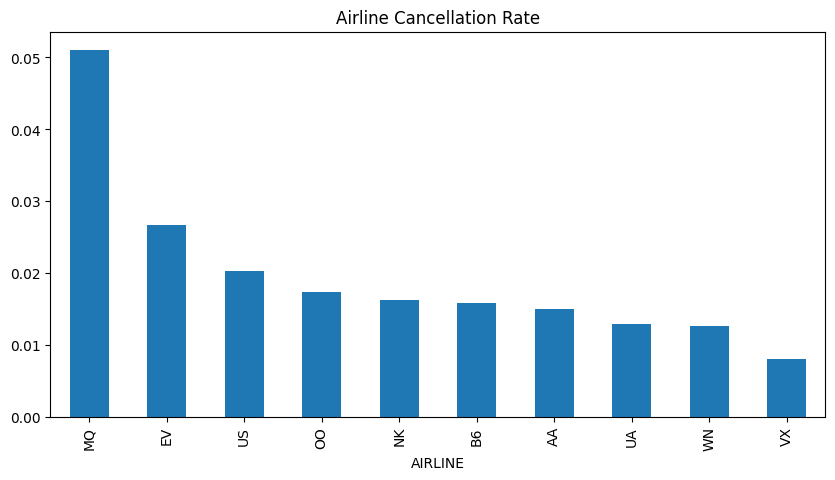

In [116]:
cancel_airline = df.groupby('AIRLINE')['ISCANCELLED'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
cancel_airline.head(10).plot(kind='bar')
plt.title("Airline Cancellation Rate")
plt.show()